
# Final — Team FX carry baseline with an adaptive macro/regime overlay

This notebook combines:

1. The team's validated FX carry strategy from `strategy.run()`.
2. The monthly macro/regime model developed in notebook 03.
3. The binary and probability-scaled exposure rules developed in notebook 04.
4. The strategy package's native `exposure` hook, so the overlay changes actual portfolio weights,
   is lagged by the engine, and pays the resulting bid/ask and roll costs.

## Critical implementation conventions

- The baseline is **imported, not rebuilt**.
- The model uses the baseline's complete net returns, including spot and carry.
- The model outputs an **unlagged** month-end exposure signal.
- `strategy.run(exposure=...)` performs the execution lag.
- The adaptive strategy is rerun through the engine; returns are not multiplied after the fact.
- Feature availability screening and preprocessing are fitted separately inside each expanding window.
- Results are compared with `run()` on the same universe and evaluation window.

The main research question is:

> Can observable macro, market-risk and carry-state variables identify months in which reducing
> exposure to the validated FX carry portfolio improves downside risk after realistic trading costs?


## 1. Environment and project paths

In [1]:

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# ---------------------------------------------------------------------
# Locate the shared repository root independently of notebook location.
# The correct root contains both strategy/ and data/raw/.
# ---------------------------------------------------------------------
START = Path.cwd().resolve()

def locate_repository(start: Path) -> Path:
    candidates = [start, *start.parents]

    # Also inspect direct children and parents' direct children. This helps
    # when the notebook lives in a personal folder such as <repo>/vidhi/.
    expanded = list(candidates)
    for candidate in candidates:
        if candidate.exists():
            try:
                expanded.extend(
                    child for child in candidate.iterdir()
                    if child.is_dir()
                )
            except PermissionError:
                pass

    seen = set()
    for candidate in expanded:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)

        if (
            (candidate / "strategy").is_dir()
            and (candidate / "data" / "raw").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root containing both "
        "'strategy/' and 'data/raw/'. Set REPO_ROOT manually in this cell."
    )

REPO_ROOT = locate_repository(START)
sys.path.insert(0, str(REPO_ROOT))

DATA_DIR = REPO_ROOT / "data" / "raw"

# Keep extension outputs outside strategy/ and cesare/outputs/.
# When the notebook is under <repo>/vidhi or <repo>/vidhi/notebooks,
# results will be written to <repo>/vidhi/outputs.
if START.name.lower() == "notebooks":
    PERSONAL_ROOT = START.parent
elif REPO_ROOT in START.parents or START == REPO_ROOT:
    PERSONAL_ROOT = START
else:
    PERSONAL_ROOT = REPO_ROOT / "vidhi"

OUTPUT_DIR = PERSONAL_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root :", REPO_ROOT)
print("Raw data folder :", DATA_DIR)
print("Output folder   :", OUTPUT_DIR)
print("Strategy exists :", (REPO_ROOT / "strategy").exists())


Repository root : C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL
Raw data folder : C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL\data\raw
Output folder   : C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL\vidhi\outputs
Strategy exists : True


## 2. Imports and research parameters

In [2]:

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler

from strategy import run

# Model design
MINIMUM_TRAINING_MONTHS = 60
MINIMUM_COLUMN_COVERAGE = 0.60
MAX_FEATURES_PER_FOLD = 80
RANDOM_STATE = 42

# Exposure design
PROBABILITY_THRESHOLD = 0.50
SCALED_LOWER_PROBABILITY = 0.35
SCALED_UPPER_PROBABILITY = 0.65

# Optional regularisation. Smaller C means stronger shrinkage.
LOGISTIC_C = 0.50

FEATURE_FILES = {
    "global_risk": "global_risk_wide.parquet",
    "em_risk": "em_risk_wide.parquet",
    "macro_market_proxies": "macro_market_proxies_wide.parquet",
    "g10_interest_rates": "g10_interest_rates_wide.parquet",
    "em_interest_rates": "em_interest_rates_wide.parquet",
    "em_onshore_rates": "em_onshore_rates_wide.parquet",
    "g10_rates_gaps": "g10_rates_gaps_wide.parquet",
    "usd_riskfree": "usd_riskfree_wide.parquet",
}


## 3. Run and reconcile the validated team baseline

In [3]:

base = run()

print(base)
print("\nBaseline configuration:")
display(pd.Series(base.config.describe(), name="value").to_frame())

print("\nBaseline summary:")
baseline_summary = base.summary()
display(baseline_summary.round(4))

print(
    f"\nOne-sided turnover per rebalance: {base.turnover:.4f}\n"
    f"Annualised cost drag:             {base.cost_drag:.4%}\n"
    f"Universe size:                    {len(base.universe)}\n"
    f"Evaluation window:                {base.window}"
)

# Reconcile with the committed ALL-book target when the file is present.
committed_path = REPO_ROOT / "cesare" / "outputs" / "strategy_summary_stats.csv"

if committed_path.exists():
    committed = pd.read_csv(committed_path, index_col=0)
    got_net = float(base.summary(benchmark=None).loc["ALL_net", "sharpe"])
    expected_net = float(committed.loc["ALL_net", "sharpe"])
    difference = abs(got_net - expected_net)

    print(
        f"Reconciliation: net Sharpe {got_net:.4f} "
        f"versus committed {expected_net:.4f} "
        f"-> {'OK' if difference < 5e-4 else 'MISMATCH'}"
    )

    if difference >= 5e-4:
        raise RuntimeError(
            "Baseline reconciliation failed. Stop here and repair the "
            "environment before interpreting any overlay results."
        )
else:
    print(
        "Committed summary file was not found. Run "
        "'python strategy/tests/test_reconciliation.py' before using results."
    )


<StrategyResult 'ALL' | 27 ccy | 2007-05-01->2026-06-30 | Sharpe gross 0.628 net 0.466>

Baseline configuration:


,value
universe,ALL
tenor,1M
signal,carry
n_buckets,None
weighting,inv_vol
max_leg_share,0.4
vol_window,60
rebal,ME
vol_target,0.1
lev_cap,4.0



Baseline summary:


,start,end,n_days,ann_return,ann_vol,daily_variance,skew,excess_kurtosis,sharpe,max_drawdown,VaR_95,VaR_99,CVaR_95,CVaR_99,hit_rate,best_day,worst_day,autocorr_1d,cagr,sortino,calmar,info_ratio
ALL_gross,2007-05-01,2026-06-30,5001,0.07029,0.111848,0.00005,-0.652152,4.579734,0.628442,-0.267829,0.010594,0.021711,0.017392,0.029186,0.544091,0.041328,-0.04906,0.010659,0.066103,0.860703,0.246809,0.497304
ALL_net,2007-05-01,2026-06-30,5001,0.052143,0.111914,0.00005,-0.648005,4.543499,0.465923,-0.293185,0.010661,0.02188,0.017493,0.029199,0.538292,0.041328,-0.04906,0.007721,0.046927,0.634117,0.16006,0.337642



One-sided turnover per rebalance: 0.6755
Annualised cost drag:             1.8147%
Universe size:                    27
Evaluation window:                (Timestamp('2007-05-01 00:00:00'), Timestamp('2026-06-30 00:00:00'))
Reconciliation: net Sharpe 0.4659 versus committed 0.4659 -> OK



## 4. Load the macro and market proxy panels

The shared raw data are read directly with `pandas.read_parquet`; this notebook does not depend on
a personal `src.data_loader` import.

Different files can have different calendars. The combined panel therefore:

- normalises all timestamps to calendar dates;
- keeps the last observation when a file contains multiple timestamps on one date;
- removes rows that are empty across every feature;
- does **not** backfill future information;
- leaves ordinary partial missingness to be handled inside each expanding training fold.


In [11]:
def read_wide_parquet(path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(path)

    print(f"\nLoading: {path.name}")
    print("Index type:", type(frame.index))
    print("Index name:", frame.index.name)
    print("First index values:", frame.index[:3].tolist())
    print("First columns:", frame.columns[:5].tolist())

    # Handle MultiIndex first.
    if isinstance(frame.index, pd.MultiIndex):
        date_level = None

        for level_number in range(frame.index.nlevels):
            values = frame.index.get_level_values(level_number)
            parsed = pd.to_datetime(values, errors="coerce")

            if parsed.notna().mean() >= 0.80:
                date_level = level_number
                break

        if date_level is not None:
            frame.index = pd.to_datetime(
                frame.index.get_level_values(date_level),
                errors="coerce",
            )

    # Try converting an existing non-default index.
    elif not isinstance(frame.index, pd.RangeIndex):
        parsed_index = pd.to_datetime(
            frame.index,
            errors="coerce",
        )

        if parsed_index.notna().mean() >= 0.80:
            frame.index = parsed_index

    # Search for a date column when the index is still not datetime.
    if not isinstance(frame.index, pd.DatetimeIndex):
        possible_names = {
            "date",
            "datetime",
            "timestamp",
            "time",
            "asof_date",
            "observation_date",
            "index",
            "__index_level_0__",
        }

        selected_date_column = None

        for column in frame.columns:
            normalized_name = str(column).strip().lower()

            if normalized_name in possible_names:
                selected_date_column = column
                break

        # As a fallback, inspect columns for date-like values.
        if selected_date_column is None:
            for column in frame.columns:
                parsed = pd.to_datetime(
                    frame[column],
                    errors="coerce",
                )

                if parsed.notna().mean() >= 0.80:
                    selected_date_column = column
                    break

        if selected_date_column is not None:
            frame[selected_date_column] = pd.to_datetime(
                frame[selected_date_column],
                errors="coerce",
            )
            frame = frame.set_index(selected_date_column)

    if not isinstance(frame.index, pd.DatetimeIndex):
        raise ValueError(
            f"{path.name}: could not identify the date field.\n"
            f"Index type: {type(frame.index)}\n"
            f"Index name: {frame.index.name}\n"
            f"Index sample: {frame.index[:5].tolist()}\n"
            f"Columns: {frame.columns[:20].tolist()}"
        )

    frame = frame.loc[frame.index.notna()].copy()
    frame.index = frame.index.normalize()
    frame = frame.sort_index()
    frame = frame.groupby(level=0).last()

    frame = frame.apply(pd.to_numeric, errors="coerce")
    frame = frame.dropna(axis=1, how="all")
    frame = frame.dropna(axis=0, how="all")

    return frame


# ---------------------------------------------------------------------
# Actually load and combine the macro files.
# ---------------------------------------------------------------------
feature_frames = []
loading_report = []

for group_name, filename in FEATURE_FILES.items():
    path = DATA_DIR / filename

    if not path.exists():
        loading_report.append(
            {
                "group": group_name,
                "file": filename,
                "status": "missing",
                "rows": 0,
                "columns": 0,
            }
        )
        continue

    try:
        frame = read_wide_parquet(path)

        frame.columns = [
            f"{group_name}__{column}"
            for column in frame.columns
        ]

        feature_frames.append(frame)

        loading_report.append(
            {
                "group": group_name,
                "file": filename,
                "status": "loaded",
                "rows": len(frame),
                "columns": frame.shape[1],
            }
        )

    except Exception as error:
        loading_report.append(
            {
                "group": group_name,
                "file": filename,
                "status": f"error: {error}",
                "rows": 0,
                "columns": 0,
            }
        )

loading_report = pd.DataFrame(loading_report)
display(loading_report)

if not feature_frames:
    raise RuntimeError(
        "No macro files loaded successfully. Inspect loading_report."
    )

market_daily = pd.concat(
    feature_frames,
    axis=1,
    join="outer",
).sort_index()

market_daily = market_daily.loc[
    ~market_daily.index.duplicated(keep="last")
]

market_daily = market_daily.dropna(how="all")

print("\nCombined daily panel:", market_daily.shape)
print(
    "Date range:",
    market_daily.index.min(),
    "to",
    market_daily.index.max(),
)
print(
    "All-empty rows:",
    int(market_daily.isna().all(axis=1).sum()),
)

display(market_daily.tail())


Loading: global_risk_wide.parquet
Index type: <class 'pandas.core.indexes.base.Index'>
Index name: date
First index values: [datetime.date(2007, 1, 1), datetime.date(2007, 1, 2), datetime.date(2007, 1, 3)]
First columns: [('BCOM Index', 'PX_LAST'), ('CL1 Comdty', 'PX_LAST'), ('CO1 Comdty', 'PX_LAST'), ('DXY Curncy', 'PX_LAST'), ('HG1 Comdty', 'PX_LAST')]

Loading: em_risk_wide.parquet
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index name: date
First index values: [Timestamp('2007-01-01 00:00:00'), Timestamp('2007-01-02 00:00:00'), Timestamp('2007-01-03 00:00:00')]
First columns: [('JPEIGLSP Index', 'PX_LAST')]

Loading: macro_market_proxies_wide.parquet
Index type: <class 'pandas.core.indexes.base.Index'>
Index name: date
First index values: [datetime.date(2007, 1, 1), datetime.date(2007, 1, 2), datetime.date(2007, 1, 3)]
First columns: [('BCOM Index', 'PX_LAST'), ('BFCIUS Index', 'PX_LAST'), ('CL1 Comdty', 'PX_LAST'), ('CO1 Comdty', 'PX_LAST'), ('CPI YOY Index'

,group,file,status,rows,columns
0,global_risk,global_risk_wide.parquet,loaded,5087,19
1,em_risk,em_risk_wide.parquet,loaded,5091,1
2,macro_market_proxies,macro_market_proxies_wide.parquet,loaded,5155,24
3,g10_interest_rates,g10_interest_rates_wide.parquet,loaded,5087,81
4,em_interest_rates,em_interest_rates_wide.parquet,loaded,5087,34
5,em_onshore_rates,em_onshore_rates_wide.parquet,loaded,7127,16
6,g10_rates_gaps,g10_rates_gaps_wide.parquet,loaded,5091,4
7,usd_riskfree,usd_riskfree_wide.parquet,loaded,5091,1



Combined daily panel: (7127, 180)
Date range: 2007-01-01 00:00:00 to 2026-07-06 00:00:00
All-empty rows: 0


,"global_risk__('BCOM Index', 'PX_LAST')","global_risk__('CL1 Comdty', 'PX_LAST')","global_risk__('CO1 Comdty', 'PX_LAST')","global_risk__('DXY Curncy', 'PX_LAST')","global_risk__('HG1 Comdty', 'PX_LAST')","global_risk__('JPMVXYEM Index', 'PX_LAST')","global_risk__('JPMVXYG7 Index', 'PX_LAST')","global_risk__('JPMVXYGL Index', 'PX_LAST')","global_risk__('MOVE Index', 'PX_LAST')","global_risk__('MXEF Index', 'PX_LAST')","global_risk__('MXWO Index', 'PX_LAST')","global_risk__('NDX Index', 'PX_LAST')","global_risk__('RTY Index', 'PX_LAST')","global_risk__('SPX Index', 'PX_LAST')","global_risk__('USGG10YR Index', 'PX_LAST')","global_risk__('USGG2YR Index', 'PX_LAST')","global_risk__('USYC2Y10 Index', 'PX_LAST')","global_risk__('VIX Index', 'PX_LAST')","global_risk__('XAU Curncy', 'PX_LAST')","em_risk__('JPEIGLSP Index', 'PX_LAST')","macro_market_proxies__('BCOM Index', 'PX_LAST')","macro_market_proxies__('BFCIUS Index', 'PX_LAST')","macro_market_proxies__('CL1 Comdty', 'PX_LAST')","macro_market_proxies__('CO1 Comdty', 'PX_LAST')","macro_market_proxies__('CPI YOY Index', 'PX_LAST')","macro_market_proxies__('CPURNSA Index', 'PX_LAST')","macro_market_proxies__('FEDL01 Index', 'PX_LAST')","macro_market_proxies__('GACGB10 Index', 'PX_LAST')","macro_market_proxies__('GACGB2 Index', 'PX_LAST')","macro_market_proxies__('GCAN10YR Index', 'PX_LAST')","macro_market_proxies__('GCAN2YR Index', 'PX_LAST')","macro_market_proxies__('GDBR10 Index', 'PX_LAST')","macro_market_proxies__('GDBR2 Index', 'PX_LAST')","macro_market_proxies__('GDP CUR$ Index', 'PX_LAST')","macro_market_proxies__('GJGB10 Index', 'PX_LAST')","macro_market_proxies__('GJGB2 Index', 'PX_LAST')","macro_market_proxies__('GUKG10 Index', 'PX_LAST')","macro_market_proxies__('GUKG2 Index', 'PX_LAST')","macro_market_proxies__('HG1 Comdty', 'PX_LAST')","macro_market_proxies__('M2% YOY Index', 'PX_LAST')","macro_market_proxies__('SOFRRATE Index', 'PX_LAST')","macro_market_proxies__('USGG10YR Index', 'PX_LAST')","macro_market_proxies__('USGG2YR Index', 'PX_LAST')","macro_market_proxies__('XAU Curncy', 'PX_LAST')","g10_interest_rates__('ADBB12M Curncy', 'PX_LAST')","g10_interest_rates__('ADBB1M Curncy', 'PX_LAST')","g10_interest_rates__('ADBB3M Curncy', 'PX_LAST')","g10_interest_rates__('ADDR1Z Curncy', 'PX_LAST')","g10_interest_rates__('ADSO1Z Curncy', 'PX_LAST')","g10_interest_rates__('ADSOA Curncy', 'PX_LAST')","g10_interest_rates__('ADSOC Curncy', 'PX_LAST')","g10_interest_rates__('ADSOF Curncy', 'PX_LAST')","g10_interest_rates__('BP0001M Index', 'PX_LAST')","g10_interest_rates__('BP0001W Index', 'PX_LAST')","g10_interest_rates__('BP0003M Index', 'PX_LAST')","g10_interest_rates__('BP0012M Index', 'PX_LAST')","g10_interest_rates__('BPSWS1Z Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSA Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSC Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSF Curncy', 'PX_LAST')",...,"g10_interest_rates__('USOSFRC Curncy', 'PX_LAST')","g10_interest_rates__('USOSFRF Curncy', 'PX_LAST')","g10_interest_rates__('USSO1Z Curncy', 'PX_LAST')","g10_interest_rates__('USSOA Curncy', 'PX_LAST')","g10_interest_rates__('USSOC Curncy', 'PX_LAST')","em_interest_rates__('BCCDIO Curncy', 'PX_LAST')","em_interest_rates__('BCSWAPD Curncy', 'PX_LAST')","em_interest_rates__('BZSTSETA Index', 'PX_LAST')","em_interest_rates__('CHSWP1 Index', 'PX_LAST')","em_interest_rates__('CHSWPC Index', 'PX_LAST')","em_interest_rates__('CLTN30DS Curncy', 'PX_LAST')","em_interest_rates__('COMM1YR Index', 'PX_LAST')","em_interest_rates__('CORRRMIN Index', 'PX_LAST')","em_interest_rates__('DTF RATE Index', 'PX_LAST')","em_interest_rates__('IDBIRATE Index', 'PX_LAST')","em_interest_rates__('IDRE1MO Index', 'PX_LAST')","em_interest_rates__('IHSWOOA Curncy', 'PX_LAST')","em_interest_rates__('JIBA12M Index', 'PX_LAST')","em_interest_rates__('JIBA1M Index', 'PX_LAST')","em_interest_rates__('JIBA3M Index', 'PX_LAST')","em_interest_rates__('JIIN1M Index', 'PX_LAST')","em_interest_rates__('KLIB1M Index


## 5. Convert daily macro levels into monthly state changes

Raw price and index levels are generally non-stationary. This function creates a generic monthly
change panel:

- strictly positive series use monthly log changes;
- other series use first differences;
- all variables receive a one-month lag before entering the model.

The lag means the row dated month-end \(t\) contains only information observed by month-end \(t-1\).
This is deliberately conservative for mixed-frequency data. For publication-sensitive economic
series, replace calendar timestamps with actual release timestamps when available.


In [12]:

def monthly_state_changes(daily_panel: pd.DataFrame) -> pd.DataFrame:
    monthly_last = daily_panel.resample("ME").last()
    transformed = {}

    for column in monthly_last.columns:
        series = monthly_last[column].astype(float)
        valid = series.dropna()

        if valid.empty:
            continue

        # Log changes are suitable for positive market-price/index series.
        # Differences are safer for rates, spreads and series that can be <= 0.
        if (valid > 0).all():
            changed = np.log(series).diff()
        else:
            changed = series.diff()

        transformed[column] = changed

    monthly = pd.DataFrame(transformed)

    # Conservative information lag.
    monthly = monthly.shift(1)
    monthly = monthly.replace([np.inf, -np.inf], np.nan)
    monthly = monthly.dropna(how="all")
    return monthly


macro_monthly = monthly_state_changes(market_daily)

print("Monthly macro-state panel:", macro_monthly.shape)
print("Date range:", macro_monthly.index.min(), "to", macro_monthly.index.max())
display(macro_monthly.tail())


Monthly macro-state panel: (233, 180)
Date range: 2007-03-31 00:00:00 to 2026-07-31 00:00:00


,"global_risk__('BCOM Index', 'PX_LAST')","global_risk__('CL1 Comdty', 'PX_LAST')","global_risk__('CO1 Comdty', 'PX_LAST')","global_risk__('DXY Curncy', 'PX_LAST')","global_risk__('HG1 Comdty', 'PX_LAST')","global_risk__('JPMVXYEM Index', 'PX_LAST')","global_risk__('JPMVXYG7 Index', 'PX_LAST')","global_risk__('JPMVXYGL Index', 'PX_LAST')","global_risk__('MOVE Index', 'PX_LAST')","global_risk__('MXEF Index', 'PX_LAST')","global_risk__('MXWO Index', 'PX_LAST')","global_risk__('NDX Index', 'PX_LAST')","global_risk__('RTY Index', 'PX_LAST')","global_risk__('SPX Index', 'PX_LAST')","global_risk__('USGG10YR Index', 'PX_LAST')","global_risk__('USGG2YR Index', 'PX_LAST')","global_risk__('USYC2Y10 Index', 'PX_LAST')","global_risk__('VIX Index', 'PX_LAST')","global_risk__('XAU Curncy', 'PX_LAST')","em_risk__('JPEIGLSP Index', 'PX_LAST')","macro_market_proxies__('BCOM Index', 'PX_LAST')","macro_market_proxies__('BFCIUS Index', 'PX_LAST')","macro_market_proxies__('CL1 Comdty', 'PX_LAST')","macro_market_proxies__('CO1 Comdty', 'PX_LAST')","macro_market_proxies__('CPI YOY Index', 'PX_LAST')","macro_market_proxies__('CPURNSA Index', 'PX_LAST')","macro_market_proxies__('FEDL01 Index', 'PX_LAST')","macro_market_proxies__('GACGB10 Index', 'PX_LAST')","macro_market_proxies__('GACGB2 Index', 'PX_LAST')","macro_market_proxies__('GCAN10YR Index', 'PX_LAST')","macro_market_proxies__('GCAN2YR Index', 'PX_LAST')","macro_market_proxies__('GDBR10 Index', 'PX_LAST')","macro_market_proxies__('GDBR2 Index', 'PX_LAST')","macro_market_proxies__('GDP CUR$ Index', 'PX_LAST')","macro_market_proxies__('GJGB10 Index', 'PX_LAST')","macro_market_proxies__('GJGB2 Index', 'PX_LAST')","macro_market_proxies__('GUKG10 Index', 'PX_LAST')","macro_market_proxies__('GUKG2 Index', 'PX_LAST')","macro_market_proxies__('HG1 Comdty', 'PX_LAST')","macro_market_proxies__('M2% YOY Index', 'PX_LAST')","macro_market_proxies__('SOFRRATE Index', 'PX_LAST')","macro_market_proxies__('USGG10YR Index', 'PX_LAST')","macro_market_proxies__('USGG2YR Index', 'PX_LAST')","macro_market_proxies__('XAU Curncy', 'PX_LAST')","g10_interest_rates__('ADBB12M Curncy', 'PX_LAST')","g10_interest_rates__('ADBB1M Curncy', 'PX_LAST')","g10_interest_rates__('ADBB3M Curncy', 'PX_LAST')","g10_interest_rates__('ADDR1Z Curncy', 'PX_LAST')","g10_interest_rates__('ADSO1Z Curncy', 'PX_LAST')","g10_interest_rates__('ADSOA Curncy', 'PX_LAST')","g10_interest_rates__('ADSOC Curncy', 'PX_LAST')","g10_interest_rates__('ADSOF Curncy', 'PX_LAST')","g10_interest_rates__('BP0001M Index', 'PX_LAST')","g10_interest_rates__('BP0001W Index', 'PX_LAST')","g10_interest_rates__('BP0003M Index', 'PX_LAST')","g10_interest_rates__('BP0012M Index', 'PX_LAST')","g10_interest_rates__('BPSWS1Z Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSA Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSC Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSF Curncy', 'PX_LAST')",...,"g10_interest_rates__('USOSFRC Curncy', 'PX_LAST')","g10_interest_rates__('USOSFRF Curncy', 'PX_LAST')","g10_interest_rates__('USSO1Z Curncy', 'PX_LAST')","g10_interest_rates__('USSOA Curncy', 'PX_LAST')","g10_interest_rates__('USSOC Curncy', 'PX_LAST')","em_interest_rates__('BCCDIO Curncy', 'PX_LAST')","em_interest_rates__('BCSWAPD Curncy', 'PX_LAST')","em_interest_rates__('BZSTSETA Index', 'PX_LAST')","em_interest_rates__('CHSWP1 Index', 'PX_LAST')","em_interest_rates__('CHSWPC Index', 'PX_LAST')","em_interest_rates__('CLTN30DS Curncy', 'PX_LAST')","em_interest_rates__('COMM1YR Index', 'PX_LAST')","em_interest_rates__('CORRRMIN Index', 'PX_LAST')","em_interest_rates__('DTF RATE Index', 'PX_LAST')","em_interest_rates__('IDBIRATE Index', 'PX_LAST')","em_interest_rates__('IDRE1MO Index', 'PX_LAST')","em_interest_rates__('IHSWOOA Curncy', 'PX_LAST')","em_interest_rates__('JIBA12M Index', 'PX_LAST')","em_interest_rates__('JIBA1M Index', 'PX_LAST')","em_interest_rates__('JIBA3M Index', 'PX_LAST')","em_interest_rates__('JIIN1M Index', 'PX_LAST')","em_interest_rates__('KLIB1M Index


## 6. Build strategy-state features and the next-month target

The updated baseline exposes the exact signal panel used by the carry sort. Carry opportunity is
therefore measured as the cross-sectional dispersion of `base.signal`, rather than using the old
personal `carry_scores.parquet`.

The model target is whether the baseline's **next monthly net return** is positive.


In [13]:

monthly_base = base.monthly(which="net").rename("baseline_net_return")
monthly_base.index = pd.to_datetime(monthly_base.index)

carry_dispersion_daily = (
    base.signal.std(axis=1, skipna=True)
    .replace([np.inf, -np.inf], np.nan)
    .rename("carry_dispersion")
)
carry_dispersion_daily.index = pd.to_datetime(carry_dispersion_daily.index)

carry_dispersion_monthly = (
    carry_dispersion_daily.resample("ME").last()
)

strategy_state = pd.DataFrame(index=monthly_base.index)
strategy_state["carry_dispersion"] = carry_dispersion_monthly
strategy_state["carry_dispersion_change"] = carry_dispersion_monthly.pct_change()
strategy_state["carry_return_1m"] = monthly_base
strategy_state["carry_return_3m"] = (
    (1.0 + monthly_base).rolling(3).apply(np.prod, raw=True) - 1.0
)
strategy_state["carry_return_6m"] = (
    (1.0 + monthly_base).rolling(6).apply(np.prod, raw=True) - 1.0
)
strategy_state["carry_return_12m"] = (
    (1.0 + monthly_base).rolling(12).apply(np.prod, raw=True) - 1.0
)
strategy_state["carry_volatility_6m"] = monthly_base.rolling(6).std()
strategy_state["carry_volatility_12m"] = monthly_base.rolling(12).std()

wealth = (1.0 + monthly_base.fillna(0.0)).cumprod()
strategy_state["carry_drawdown"] = wealth.div(wealth.cummax()).sub(1.0)

# All state variables are lagged so row t only uses information known
# before the return being predicted for t+1.
strategy_state = strategy_state.shift(1)

dataset = pd.concat(
    [
        monthly_base,
        strategy_state.add_prefix("strategy__"),
        macro_monthly.add_prefix("macro__"),
    ],
    axis=1,
).sort_index()

dataset["next_return"] = monthly_base.shift(-1)
dataset["target_next_positive"] = (
    dataset["next_return"] > 0
).astype(float)
dataset.loc[dataset["next_return"].isna(), "target_next_positive"] = np.nan

dataset = dataset.loc[
    dataset["next_return"].notna()
]

NON_FEATURE_COLUMNS = {
    "baseline_net_return",
    "next_return",
    "target_next_positive",
}
candidate_features = [
    column for column in dataset.columns
    if column not in NON_FEATURE_COLUMNS
]

print("Modelling dataset:", dataset.shape)
print("Candidate features:", len(candidate_features))
display(
    dataset[
        ["baseline_net_return", "next_return", "target_next_positive"]
        + candidate_features[:5]
    ].tail()
)


Modelling dataset: (229, 192)
Candidate features: 189


,baseline_net_return,next_return,target_next_positive,strategy__carry_dispersion,strategy__carry_dispersion_change,strategy__carry_return_1m,strategy__carry_return_3m,strategy__carry_return_6m
date,,,,,,,,
2026-01-31,-0.001118,0.024172,1.0,0.062707,0.003638,0.001844,0.106149,0.233282
2026-02-28,0.024172,0.052884,1.0,0.054381,-0.132778,-0.001118,0.042966,0.206816
2026-03-31,0.052884,0.000301,1.0,0.064328,0.182921,0.024172,0.024912,0.205342
2026-04-30,0.000301,0.020480,1.0,0.096517,0.500388,0.052884,0.077128,0.191464
2026-05-31,0.020480,0.094063,1.0,0.070334,-0.271275,0.000301,0.078658,0.125004



## 7. Expanding-window logistic model with fold-specific feature screening

For each prediction month:

1. Train only on earlier months.
2. Screen columns using coverage and variation measured only in that training sample.
3. Rank surviving columns by absolute univariate correlation with the training target.
4. Retain at most `MAX_FEATURES_PER_FOLD`.
5. Fit median imputation, standardisation and regularised logistic regression on the training sample.
6. Generate one genuinely out-of-sample probability.

This corrects the full-sample feature-screening leakage in the earlier notebook.


In [ ]:

def expanding_logistic_probabilities(
    frame: pd.DataFrame,
    feature_columns: list[str],
    minimum_training_months: int = 60,
    minimum_coverage: float = 0.60,
    maximum_features: int = 80,
    random_state: int = 42,
    logistic_c: float = 0.50,
):
    probabilities = pd.Series(
        np.nan,
        index=frame.index,
        name="probability",
        dtype=float,
    )
    selected_features_by_date = {}
    coefficient_rows = []
    diagnostics = []

    y_all = frame["target_next_positive"].astype(float)

    for test_position in range(minimum_training_months, len(frame)):
        test_date = frame.index[test_position]
        train = frame.iloc[:test_position].copy()
        test = frame.iloc[[test_position]].copy()

        y_train = train["target_next_positive"].dropna()
        if y_train.nunique() < 2:
            continue

        train = train.loc[y_train.index]
        X_train_raw = train[feature_columns]
        X_test_raw = test[feature_columns]

        # Coverage and variation are assessed only in the historical fold.
        coverage = X_train_raw.notna().mean()
        selected = coverage[coverage >= minimum_coverage].index.tolist()
        selected = [
            column for column in selected
            if X_train_raw[column].nunique(dropna=True) > 1
        ]

        if not selected:
            continue

        # Fold-specific dimensionality control.
        correlations = (
            X_train_raw[selected]
            .corrwith(y_train)
            .abs()
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .sort_values(ascending=False)
        )

        if correlations.empty:
            continue

        selected = correlations.head(maximum_features).index.tolist()
        selected_features_by_date[test_date] = selected

        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()
        model = LogisticRegression(
            C=logistic_c,
            penalty="l2",
            solver="liblinear",
            max_iter=2_000,
            random_state=random_state,
        )

        X_train = imputer.fit_transform(X_train_raw[selected])
        X_train = scaler.fit_transform(X_train)

        X_test = imputer.transform(X_test_raw[selected])
        X_test = scaler.transform(X_test)

        model.fit(X_train, y_train.astype(int))
        probability = float(model.predict_proba(X_test)[0, 1])
        probabilities.loc[test_date] = probability

        coefficient_rows.append(
            pd.Series(
                model.coef_[0],
                index=selected,
                name=test_date,
            )
        )

        diagnostics.append(
            {
                "date": test_date,
                "training_months": len(train),
                "selected_features": len(selected),
                "positive_training_rate": y_train.mean(),
                "probability": probability,
            }
        )

    coefficients = (
        pd.DataFrame(coefficient_rows)
        if coefficient_rows
        else pd.DataFrame()
    )
    diagnostics = (
        pd.DataFrame(diagnostics).set_index("date")
        if diagnostics
        else pd.DataFrame()
    )

    return probabilities, coefficients, diagnostics, selected_features_by_date

probability, rolling_coefficients, model_diagnostics, selected_features = (
    expanding_logistic_probabilities(
        dataset,
        candidate_features,
        minimum_training_months=MINIMUM_TRAINING_MONTHS,
        minimum_coverage=MINIMUM_COLUMN_COVERAGE,
        maximum_features=MAX_FEATURES_PER_FOLD,
        random_state=RANDOM_STATE,
        logistic_c=LOGISTIC_C,
    )
)

dataset["probability"] = probability

print("Out-of-sample probabilities:", int(probability.notna().sum()))
display(
    dataset[
        ["next_return", "target_next_positive", "probability"]
    ].dropna().tail(12)
)

if probability.notna().sum() == 0:
    raise RuntimeError(
        "The model generated no probabilities. Inspect data coverage, "
        "the minimum training window and target availability."
    )


Out-of-sample probabilities: 169


,next_return,target_next_positive,probability
date,,,
2025-06-30,0.020787,1.0,0.570033
2025-07-31,0.025424,1.0,0.442389
2025-08-31,0.065148,1.0,0.563361
2025-09-30,0.059394,1.0,0.112805
2025-10-31,0.042212,1.0,0.355402
2025-11-30,0.001844,1.0,0.375876
2025-12-31,-0.001118,0.0,0.354912
2026-01-31,0.024172,1.0,0.408158
2026-02-28,0.052884,1.0,0.662550


In [32]:
print(model.classes)

NameError: name 'model' is not defined

## 8. Out-of-sample model diagnostics

,value
observations,169.0000
positive_rate,0.5976
accuracy,0.4497
log_loss,1.2527
roc_auc,0.4173


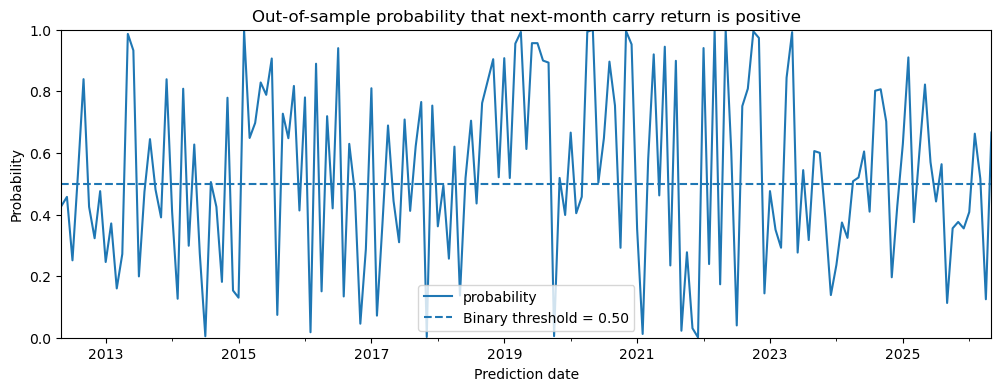

In [15]:

evaluation = dataset[
    ["target_next_positive", "probability", "next_return"]
].dropna()

y_true = evaluation["target_next_positive"].astype(int)
y_probability = evaluation["probability"].clip(1e-6, 1 - 1e-6)
y_predicted = (y_probability >= PROBABILITY_THRESHOLD).astype(int)

model_metrics = {
    "observations": len(evaluation),
    "positive_rate": y_true.mean(),
    "accuracy": accuracy_score(y_true, y_predicted),
    "log_loss": log_loss(y_true, y_probability),
    "roc_auc": (
        roc_auc_score(y_true, y_probability)
        if y_true.nunique() == 2
        else np.nan
    ),
}

display(pd.Series(model_metrics, name="value").to_frame().round(4))

ax = probability.dropna().plot(
    figsize=(12, 4),
    title="Out-of-sample probability that next-month carry return is positive",
)
ax.axhline(
    PROBABILITY_THRESHOLD,
    linestyle="--",
    label=f"Binary threshold = {PROBABILITY_THRESHOLD:.2f}",
)
ax.set_ylim(0, 1)
ax.set_ylabel("Probability")
ax.set_xlabel("Prediction date")
ax.legend()
plt.show()



## 9. Convert probabilities into unlagged exposure signals

Two versions of the original adaptive overlay are retained:

- **Binary gate:** fully invested when probability is at least 50%; otherwise zero exposure.
- **Probability-scaled gate:** linearly maps probabilities from 0 at 35% to 1 at 65%.

These series are deliberately **not shifted here**. The strategy engine samples them at the rebalance
date and applies its own execution lag.


In [16]:

def probability_exposure(
    probability_series: pd.Series,
    lower_probability: float = 0.35,
    upper_probability: float = 0.65,
) -> pd.Series:
    if upper_probability <= lower_probability:
        raise ValueError(
            "upper_probability must be greater than lower_probability."
        )

    exposure = (
        (probability_series - lower_probability)
        / (upper_probability - lower_probability)
    )
    return exposure.clip(lower=0.0, upper=1.0)


binary_exposure = (
    probability.ge(PROBABILITY_THRESHOLD)
    .astype(float)
    .where(probability.notna())
    .rename("binary_exposure")
)

scaled_exposure = (
    probability_exposure(
        probability,
        lower_probability=SCALED_LOWER_PROBABILITY,
        upper_probability=SCALED_UPPER_PROBABILITY,
    )
    .where(probability.notna())
    .rename("probability_scaled_exposure")
)

exposure_panel = pd.concat(
    [probability, binary_exposure, scaled_exposure],
    axis=1,
)

display(exposure_panel.dropna().tail(12))
display(exposure_panel.describe().round(4))


,probability,binary_exposure,probability_scaled_exposure
date,,,
2025-06-30,0.570033,1.0,0.733444
2025-07-31,0.442389,0.0,0.307963
2025-08-31,0.563361,1.0,0.711205
2025-09-30,0.112805,0.0,0.000000
2025-10-31,0.355402,0.0,0.018005
2025-11-30,0.375876,0.0,0.086252
2025-12-31,0.354912,0.0,0.016374
2026-01-31,0.408158,0.0,0.193859
2026-02-28,0.662550,1.0,1.000000


,probability,binary_exposure,probability_scaled_exposure
count,169.0000,169.0000,169.0000
mean,0.5314,0.5207,0.5266
std,0.2879,0.5011,0.4378
min,0.0010,0.0000,0.0000
25%,0.3171,0.0000,0.0000
50%,0.5160,1.0000,0.5532
75%,0.7802,1.0000,1.0000
max,1.0000,1.0000,1.0000



## 10. Rerun the shared strategy with each exposure hook

This is the central correction relative to the earlier adaptive-backtest notebook.

The engine now:

- samples the unlagged exposure at its rebalance dates;
- lags execution consistently with the baseline;
- scales actual portfolio weights;
- recalculates turnover;
- charges the trades generated by switching exposure;
- reports gross and net performance on the same baseline window.

Dates before the first probability are fully invested by design. This preserves the full common
evaluation window while ensuring that the adaptive section is purely out of sample.


In [17]:

binary_result = run(
    exposure=binary_exposure,
    name="adaptive_binary_gate",
)

scaled_result = run(
    exposure=scaled_exposure,
    name="adaptive_probability_scaled",
)

results = {
    "static_baseline": base,
    "binary_gate": binary_result,
    "probability_scaled": scaled_result,
}

print("Adaptive runs completed.")


Adaptive runs completed.


## 11. Apples-to-apples gross and net comparison

In [18]:

summary_rows = []

for strategy_name, result in results.items():
    summary = result.summary(benchmark=None)

    for return_type in ["gross", "net"]:
        row_name = next(
            index for index in summary.index
            if str(index).lower().endswith(f"_{return_type}")
        )
        row = summary.loc[row_name].copy()
        row["strategy"] = strategy_name
        row["return_type"] = return_type
        row["turnover"] = result.turnover
        row["cost_drag"] = result.cost_drag
        summary_rows.append(row)

comparison_summary = (
    pd.DataFrame(summary_rows)
    .set_index(["strategy", "return_type"])
)

preferred_columns = [
    column for column in [
        "ann_return",
        "ann_vol",
        "sharpe",
        "sortino",
        "calmar",
        "max_drawdown",
        "skew",
        "hit_rate",
        "turnover",
        "cost_drag",
    ]
    if column in comparison_summary.columns
]

display(comparison_summary[preferred_columns].round(4))


ann_return  ann_vol  sharpe  sortino  calmar  max_drawdown    skew  hit_rate  turnover  cost_drag
strategy           return_type                                                                                                   
static_baseline    gross            0.0703   0.1118  0.6284   0.8607  0.2468       -0.2678 -0.6522    0.5441    0.6755     0.0181
                   net              0.0521   0.1119  0.4659   0.6341  0.1601       -0.2932 -0.6480    0.5383    0.6755     0.0181
binary_gate        gross            0.0265   0.0894  0.2965   0.4018  0.0657       -0.3463 -0.7611    0.3455    0.9257     0.0192
                   net              0.0072   0.0896  0.0809   0.1087  0.0083       -0.3879 -0.7586    0.3411    0.9257     0.0192
probability_scaled gross            0.0259   0.0870  0.2972   0.4008  0.0690       -0.3232 -0.8419    0.4305    0.8932     0.0187
                   net              0.0072   0.0872  0.0823   0.1101  0.0086       -0.3936 -0.8393    0.4233    0.8932     0.0187


### Out-of-sample comparison only

Because dates before the first model probability are fully invested, the full-window adaptive and
static paths are identical before the model begins. The table below isolates the actual model period.


In [19]:

first_prediction_date = probability.first_valid_index()

if first_prediction_date is None:
    raise RuntimeError("No first prediction date exists.")

oos_results = {
    name: result.reslice(first_prediction_date, None)
    for name, result in results.items()
}

oos_summary_rows = []

for strategy_name, result in oos_results.items():
    summary = result.summary(benchmark=None)

    for return_type in ["gross", "net"]:
        row_name = next(
            index for index in summary.index
            if str(index).lower().endswith(f"_{return_type}")
        )
        row = summary.loc[row_name].copy()
        row["strategy"] = strategy_name
        row["return_type"] = return_type
        row["turnover"] = result.turnover
        row["cost_drag"] = result.cost_drag
        oos_summary_rows.append(row)

oos_comparison_summary = (
    pd.DataFrame(oos_summary_rows)
    .set_index(["strategy", "return_type"])
)

print("Out-of-sample start:", first_prediction_date.date())
display(oos_comparison_summary[preferred_columns].round(4))


Out-of-sample start: 2012-05-31


ann_return  ann_vol  sharpe  sortino  calmar  max_drawdown    skew  hit_rate  turnover  cost_drag
strategy           return_type                                                                                                   
static_baseline    gross            0.0826   0.1098  0.7520   1.0347  0.2968       -0.2678 -0.6508    0.5525    0.6551     0.0175
                   net              0.0650   0.1099  0.5918   0.8095  0.2072       -0.2932 -0.6441    0.5471    0.6551     0.0175
binary_gate        gross            0.0229   0.0768  0.2988   0.4051  0.1037       -0.1947 -0.8117    0.2823    0.9936     0.0190
                   net              0.0039   0.0771  0.0511   0.0685  0.0043       -0.2251 -0.8047    0.2787    0.9936     0.0190
probability_scaled gross            0.0221   0.0731  0.3023   0.4061  0.1135       -0.1727 -0.9861    0.3979    0.9497     0.0182
                   net              0.0038   0.0734  0.0524   0.0697  0.0049       -0.2334 -0.9762    0.3906    0.9497     0.0182

## 12. Wealth and drawdown charts from engine-produced net returns

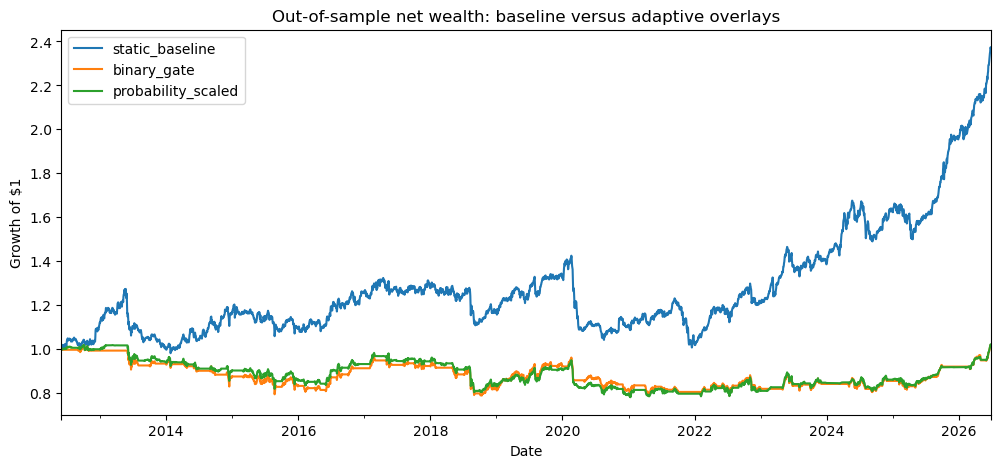

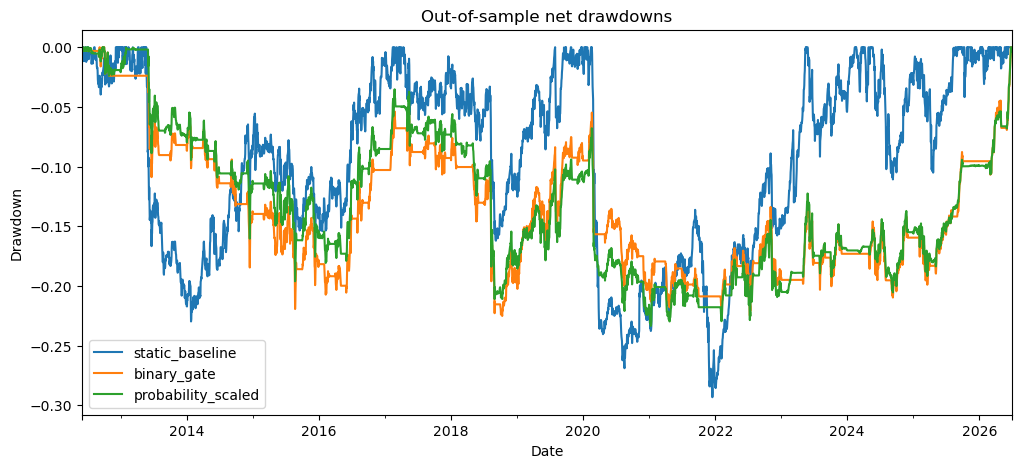

In [20]:

net_returns = pd.concat(
    {
        name: result.net
        for name, result in results.items()
    },
    axis=1,
).dropna(how="all")

net_returns = net_returns.loc[first_prediction_date:]

wealth = (1.0 + net_returns.fillna(0.0)).cumprod()
wealth = wealth.div(wealth.iloc[0])

wealth.plot(
    figsize=(12, 5),
    title="Out-of-sample net wealth: baseline versus adaptive overlays",
)
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.show()


def drawdown_from_returns(returns: pd.Series) -> pd.Series:
    path = (1.0 + returns.fillna(0.0)).cumprod()
    return path.div(path.cummax()).sub(1.0)


drawdowns = net_returns.apply(drawdown_from_returns)
drawdowns.plot(
    figsize=(12, 5),
    title="Out-of-sample net drawdowns",
)
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.show()


In [24]:
binary_exposure.describe()

count    169.000000
mean       0.520710
std        0.501056
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: binary_exposure, dtype: float64

In [25]:
scaled_exposure.describe()

count    169.000000
mean       0.526627
std        0.437820
min        0.000000
25%        0.000000
50%        0.553178
75%        1.000000
max        1.000000
Name: probability_scaled_exposure, dtype: float64

In [26]:
dataset["probability"].describe()

count    169.000000
mean       0.531436
std        0.287895
min        0.001031
25%        0.317092
50%        0.515953
75%        0.780217
max        0.999996
Name: probability, dtype: float64

In [27]:
comparison = pd.DataFrame({
    "prob": dataset["probability"],
    "next_return": dataset["next_return"]
}).dropna()

comparison["invest"] = comparison["prob"] >= 0.5

comparison.groupby("invest")["next_return"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
invest,,,,
False,81,0.008775,0.006445,0.033900
True,88,0.002782,0.001044,0.031408


In [34]:
comparison = pd.DataFrame({
    "prob": dataset["probability"],
    "next_return": dataset["next_return"]
}).dropna()

comparison["invest"] = comparison["prob"] < 0.5

comparison.groupby("invest")["next_return"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
invest,,,,
False,88,0.002782,0.001044,0.031408
True,81,0.008775,0.006445,0.033900


In [35]:
print(model_metrics)

{'observations': 169, 'positive_rate': np.float64(0.5976331360946746), 'accuracy': 0.44970414201183434, 'log_loss': 1.2526844122239724, 'roc_auc': np.float64(0.41729761211415256)}


## 13. Exposure, turnover and cost diagnostics

,mean_model_exposure,fraction_zero_exposure,turnover,annual_cost_drag
static_baseline,1.0000,0.0000,0.6755,0.0181
binary_gate,0.5207,0.4793,0.9257,0.0192
probability_scaled,0.5266,0.2663,0.8932,0.0187


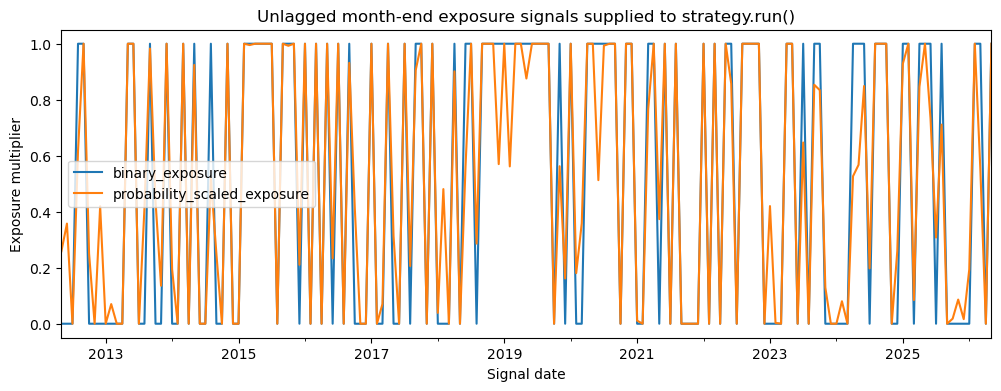

In [21]:

diagnostic_table = pd.DataFrame(
    {
        "mean_model_exposure": [
            1.0,
            binary_exposure.dropna().mean(),
            scaled_exposure.dropna().mean(),
        ],
        "fraction_zero_exposure": [
            0.0,
            binary_exposure.dropna().eq(0).mean(),
            scaled_exposure.dropna().eq(0).mean(),
        ],
        "turnover": [
            base.turnover,
            binary_result.turnover,
            scaled_result.turnover,
        ],
        "annual_cost_drag": [
            base.cost_drag,
            binary_result.cost_drag,
            scaled_result.cost_drag,
        ],
    },
    index=[
        "static_baseline",
        "binary_gate",
        "probability_scaled",
    ],
)

display(diagnostic_table.round(4))

exposure_panel[
    ["binary_exposure", "probability_scaled_exposure"]
].dropna().plot(
    figsize=(12, 4),
    title="Unlagged month-end exposure signals supplied to strategy.run()",
)
plt.ylabel("Exposure multiplier")
plt.xlabel("Signal date")
plt.ylim(-0.05, 1.05)
plt.show()


## 14. Regime analysis

In [22]:

regime_dataset = dataset[
    ["next_return", "probability"]
].dropna().copy()

regime_dataset["regime"] = pd.cut(
    regime_dataset["probability"],
    bins=[-np.inf, 0.40, 0.60, np.inf],
    labels=["risk_off", "neutral", "risk_on"],
)

regime_summary = (
    regime_dataset
    .groupby("regime", observed=False)
    .agg(
        observations=("next_return", "size"),
        mean_next_return=("next_return", "mean"),
        median_next_return=("next_return", "median"),
        positive_return_rate=(
            "next_return",
            lambda values: (values > 0).mean(),
        ),
        mean_probability=("probability", "mean"),
    )
)

display(regime_summary.round(4))


,observations,mean_next_return,median_next_return,positive_return_rate,mean_probability
regime,,,,,
risk_off,58,0.0116,0.0078,0.6552,0.2141
neutral,37,0.0038,0.0070,0.6486,0.4751
risk_on,74,0.0019,0.0005,0.5270,0.8083


## 15. Save reproducible outputs

In [23]:

# Strategy and model outputs
dataset.to_parquet(
    OUTPUT_DIR / "adaptive_regime_dataset_final.parquet"
)
exposure_panel.to_csv(
    OUTPUT_DIR / "adaptive_exposure_signals_final.csv"
)
rolling_coefficients.to_csv(
    OUTPUT_DIR / "adaptive_rolling_coefficients_final.csv"
)
model_diagnostics.to_csv(
    OUTPUT_DIR / "adaptive_model_diagnostics_final.csv"
)

comparison_summary.to_csv(
    OUTPUT_DIR / "adaptive_full_window_summary_final.csv"
)
oos_comparison_summary.to_csv(
    OUTPUT_DIR / "adaptive_oos_summary_final.csv"
)
net_returns.to_csv(
    OUTPUT_DIR / "adaptive_oos_net_returns_final.csv"
)
regime_summary.to_csv(
    OUTPUT_DIR / "adaptive_regime_summary_final.csv"
)

configuration = {
    "minimum_training_months": MINIMUM_TRAINING_MONTHS,
    "minimum_column_coverage": MINIMUM_COLUMN_COVERAGE,
    "maximum_features_per_fold": MAX_FEATURES_PER_FOLD,
    "logistic_c": LOGISTIC_C,
    "probability_threshold": PROBABILITY_THRESHOLD,
    "scaled_lower_probability": SCALED_LOWER_PROBABILITY,
    "scaled_upper_probability": SCALED_UPPER_PROBABILITY,
    "random_state": RANDOM_STATE,
    **{
        f"baseline__{key}": value
        for key, value in base.config.describe().items()
    },
}
pd.Series(configuration, name="value").to_csv(
    OUTPUT_DIR / "adaptive_final_configuration.csv"
)

print("Saved outputs to:", OUTPUT_DIR)


Saved outputs to: C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL\vidhi\outputs



## 16. Interpretation checklist

A valid conclusion should answer all of the following:

1. Did the baseline reconcile before the overlay was run?
2. Does the adaptive strategy improve **out-of-sample net** Sharpe, Sortino or maximum drawdown?
3. Is any improvement large enough to survive the additional turnover and cost drag?
4. Is the result present for both the binary and continuous versions, or only one arbitrary mapping?
5. Is the model invested often enough for the comparison to be economically meaningful?
6. Are results stable around nearby probability thresholds and regularisation values?
7. Do coefficients and selected features have plausible signs, rather than unstable month-to-month noise?
8. Were Bloomberg macro observations timestamped by actual availability, especially for revised
   economic data?

A static baseline outperforming the adaptive versions is not an implementation failure by itself.
It can be the correct empirical result. The implementation is credible here because both portfolios
are generated by the same shared engine and all overlay-induced trading is costed.
